In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from model import Dendrite, Soma, Neuron

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
TAU_T = 60.0
TAU_E = 60.0
TAU_P = 120.0
BETA  = 0.01
S_BASE = 100.0

S_TAG = 1.0
S_EARLY = 1.0
S_PRODUCT = 1.0
W_TAG = 0.67
W_EARLY = 0.67

# Scenario 1: Strong Stimulation Alone

**Hypothesis**: Smooth progression into L-LTP due to plasticity products also increasing as a part of strong stimulation. There will be some decay

In [12]:
dendrite = Dendrite(TAU_T, TAU_E, BETA)
soma = Soma(TAU_P)
neuron = Neuron([dendrite], soma, S_BASE)

In [13]:
events = [{
    "time": 0,
    "type": "strong",
    "i": 0,
    "s": S_TAG,
    "e": S_EARLY,
    "P": S_PRODUCT
}]

t,y = neuron.run(events, 480)
(s0,) = neuron.strengths(y)

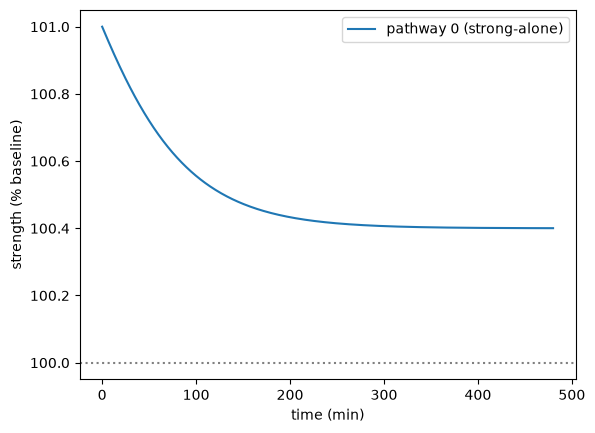

final L0 = 0.400


In [14]:
plt.plot(t, s0, label="pathway 0 (strong-alone)")
plt.axhline(S_BASE, color="grey", ls=":")
plt.xlabel("time (min)"); plt.ylabel("strength (% baseline)")
plt.legend(); plt.show()

print(f"final L0 = {y[2][-1]:.3f}")

# Scenario 2: Weak Stimulus Alone

**Hypothesis**: Without an accompanying increase in plasticity products, the early potentiation will leak to 0.

In [15]:
dendrite = Dendrite(TAU_T, TAU_E, BETA)
soma = Soma(TAU_P)
neuron = Neuron([dendrite], soma, S_BASE)

In [16]:
events = [{
    "time": 0,
    "type": "weak",
    "i": 0,
    "s": S_TAG,
    "e": S_EARLY,
    "P": S_PRODUCT
}]

t,y = neuron.run(events, 480)
(s0,) = neuron.strengths(y)

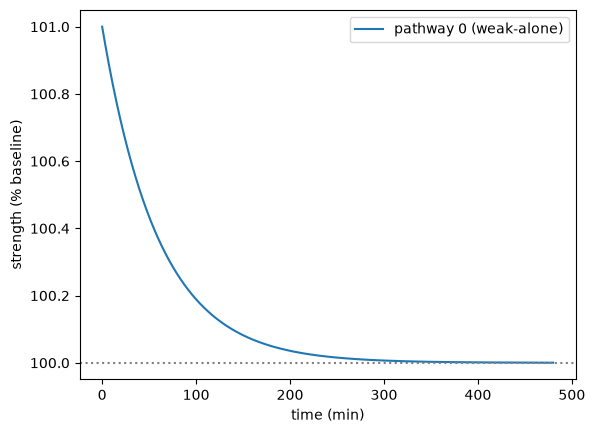

final L0 = 0.000


In [17]:
plt.plot(t, s0, label="pathway 0 (weak-alone)")
plt.axhline(S_BASE, color="grey", ls=":")
plt.xlabel("time (min)"); plt.ylabel("strength (% baseline)")
plt.legend(); plt.show()

print(f"final L0 = {y[2][-1]:.3f}")

# Scenario 3: Associative Testing

**Hypothesis**: With simultaneous strong stimulation, the weak stimulus should be able endure do to increase in plasticity products.

In [46]:
dendrite_strong = Dendrite(TAU_T, TAU_E, BETA)
dendrite_weak = Dendrite(TAU_T, TAU_E, BETA)
soma = Soma(TAU_P)
neuron = Neuron([dendrite_strong, dendrite_weak], soma, S_BASE)

In [47]:
events = [{
    "time": 0,
    "type": "strong",
    "i": 0,
    "s": S_TAG,
    "e": S_EARLY,
    "P": S_PRODUCT
}, {
    "time": 0,
    "type": "weak",
    "i": 1,
    "s": W_TAG,
    "e": W_EARLY,
    "P": S_PRODUCT
}
]

t,y = neuron.run(events, 480)
(s0,s1) = neuron.strengths(y)

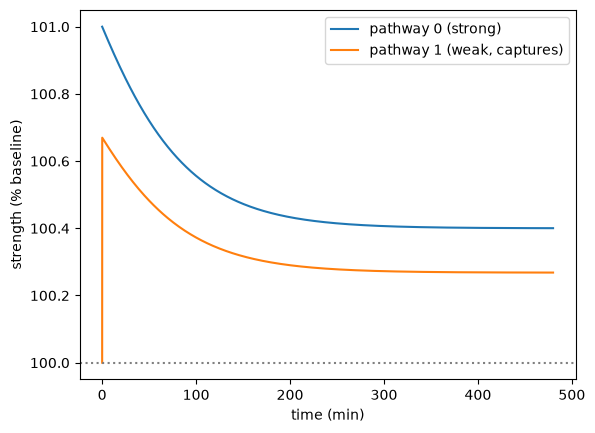

In [50]:
plt.plot(t, s0, label="pathway 0 (strong)")
plt.plot(t, s1, label="pathway 1 (weak, captures)")
plt.axhline(S_BASE, color="grey", ls=":")
plt.xlabel("time (min)"); plt.ylabel("strength (% baseline)")
plt.legend(); plt.show()

In [53]:
s0.shape

(484,)

# Scenario 4: Sweep Testing

**Hypothesis**: Delay between strong stimulus and weak stimulus will reduce capture effect for the weak stimulus since there will be less plasticity product.

In [68]:
delays = [0, 30, 60, 90, 120, 180, 240, 360]
results = []

plt.figure(figsize=(9, 5.5))
cmap = plt.cm.viridis
strong_plotted = False

<Figure size 900x550 with 0 Axes>

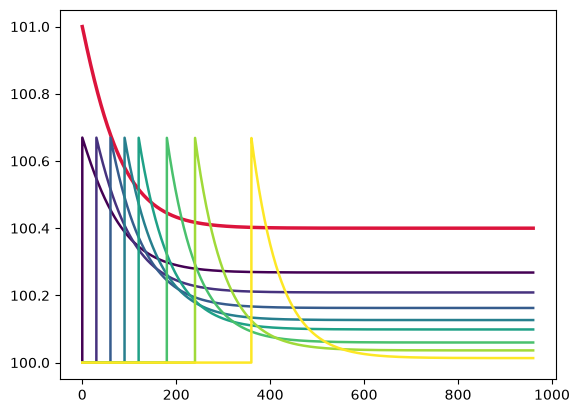

In [69]:
for k, d in enumerate(delays):
    neuron = Neuron([Dendrite(TAU_T, TAU_E, BETA), Dendrite(TAU_T, TAU_E, BETA)], Soma(TAU_P), S_BASE)

    events = [
        {"time": 0,     "type": "strong", "i": 0,
         "s": S_TAG, "e": S_EARLY, "P": S_PRODUCT},
        {"time": d, "type": "weak",   "i": 1,
         "s": W_TAG, "e": W_EARLY},
    ]
    t, y = neuron.run(events, 960)
    results.append(y[5][-1])

    s0, s1 = neuron.strengths(y)
    if not strong_plotted:
        plt.plot(t, s0, color="crimson", lw=2.5, label="pathway 0 (strong)")
        strong_plotted = True
    plt.plot(t, s1, color=cmap(k / (len(delays) - 1)), lw=1.8, label=f"weak, delay {d} min")

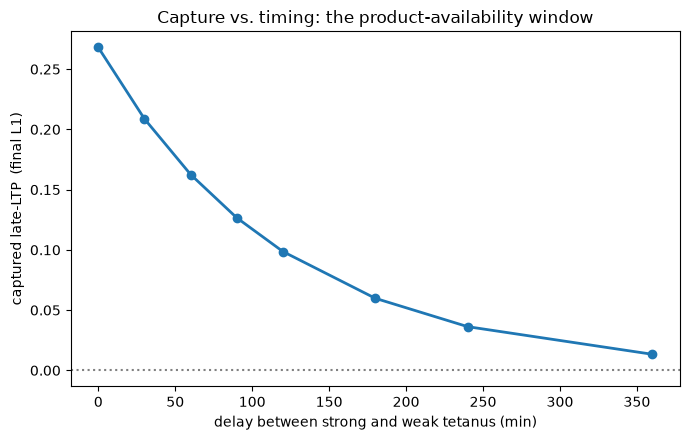

In [70]:
plt.figure(figsize=(7, 4.5))
plt.plot(delays, results, "o-", lw=2)
plt.axhline(0, color="grey", ls=":")
plt.xlabel("delay between strong and weak tetanus (min)")
plt.ylabel("captured late-LTP  (final L1)")
plt.title("Capture vs. timing: the product-availability window")
plt.tight_layout()
plt.show()